In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [2]:
data = pd.read_csv("../datasets/real_estate_properties_data_cleaned.csv")

In [3]:
X = data.copy().drop(columns = "price")
y = data["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [4]:
n_estimators = [100, 200, 300]
max_depth = [3, 5, 7, 9, 10, None]
min_samples_leaf = [1, 2, 4]

rf_params = []

for n in n_estimators:
    for depth in max_depth:
        for leaf in min_samples_leaf:
            rf_params.append({
                "n_estimators": n,
                "max_depth": depth,
                "min_samples_leaf": leaf
            })

In [5]:
kf = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [6]:
fold_results = []

for param in rf_params:
    mae_results = []
    rmse_results = []
    r2_results = []
    for fold, (train_index, validation_index) in enumerate(kf.split(X_train)):

        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]

        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        fold_model = RandomForestRegressor(
            **param,
            random_state = 42,
            n_jobs = -1
        )

        fold_model.fit(X_fold_train, y_fold_train)

        validation_predictions = fold_model.predict(X_fold_validation)

        mae = mean_absolute_error(y_fold_validation, validation_predictions)
        mae_results.append(mae)

        rmse = root_mean_squared_error(y_fold_validation, validation_predictions)
        rmse_results.append(rmse)

        r2 = r2_score(y_fold_validation, validation_predictions)
        r2_results.append(r2)

    fold_results.append({
        "MAE": np.array(mae_results).mean(),
        "RMSE": np.array(rmse_results).mean(),
        "R2": np.array(r2_results).mean()
    })

In [7]:
fold_results = pd.DataFrame(fold_results)
ranked_results = fold_results.sort_values(
    by = ["R2", "RMSE", "MAE"],
    ascending = [False, True, True]
)
best_index = ranked_results.index[0]
best_params = rf_params[best_index]

print(f"Best parameters: {best_params}")

Best parameters: {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 4}


In [8]:
best_rf_reg_model = RandomForestRegressor(
    **best_params,
    random_state = 42,
    n_jobs = -1
)

best_rf_reg_model.fit(X_train, y_train)

test_predictions = best_rf_reg_model.predict(X_test)
train_predictions = best_rf_reg_model.predict(X_train)

In [9]:
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
train_rmse = root_mean_squared_error(y_train, train_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

In [10]:
rf_results = pd.DataFrame({
    "Metric": [
        "MSE",
        "MAE",
        "RMSE",
        "R2"
    ],
    "Training": [
        train_mse,
        train_mae,
        train_rmse,
        train_r2
    ],
    "Testing": [
        test_mse,
        test_mae,
        test_rmse,
        test_r2
    ]
})

rf_melt_results = rf_results.melt(
    id_vars = "Metric",
    var_name = "Dataset",
    value_name = "Score"
)

print(rf_results)

  Metric      Training       Testing
0    MSE  3.888434e+12  2.347583e+12
1    MAE  6.995930e+05  6.581218e+05
2   RMSE  1.971911e+06  1.532182e+06
3     R2  6.924267e-01  7.628352e-01


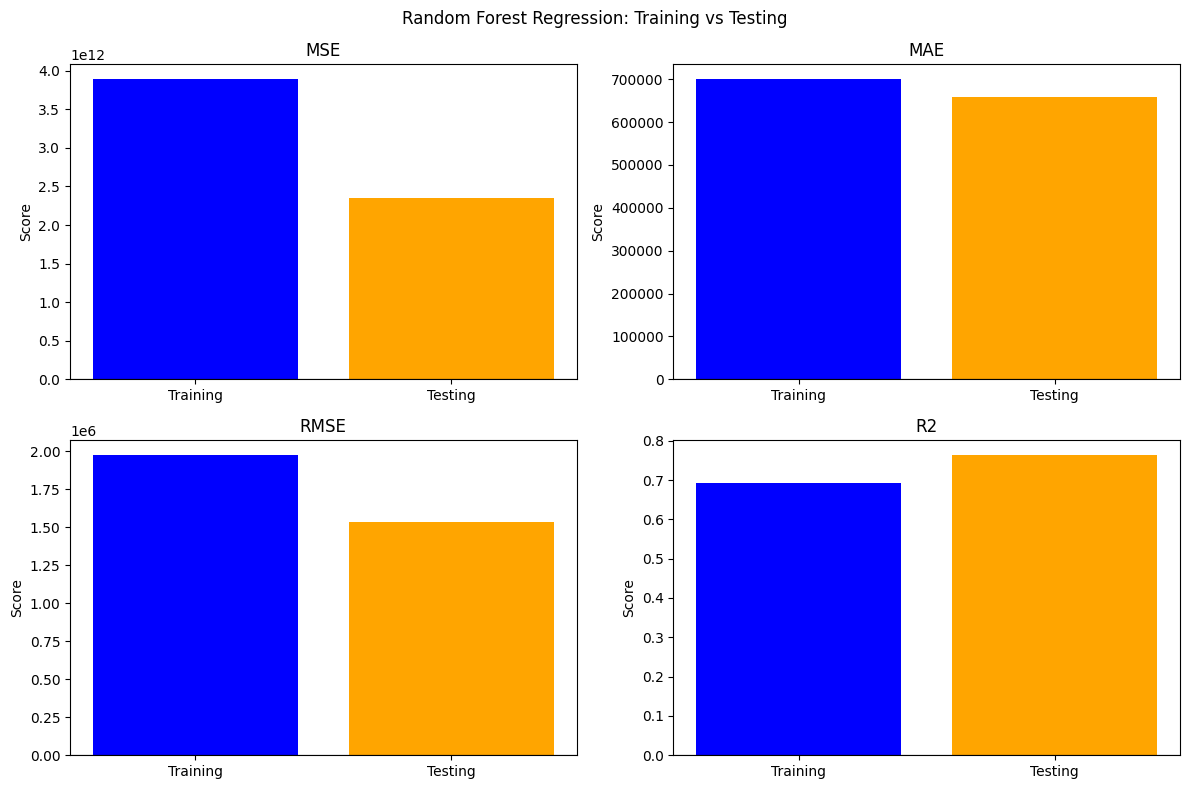

In [11]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

for ax, metric in zip(axes.flat, rf_results["Metric"]):
    metric_data = rf_melt_results[rf_melt_results["Metric"] == metric]

    ax.bar(
        metric_data["Dataset"],
        metric_data["Score"],
        color = metric_data["Dataset"].map({
            "Training": "blue",
            "Testing": "orange"
        })
    )

    ax.axhline(0, color = "black", linewidth = 0.8)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Score")

fig.suptitle("Random Forest Regression: Training vs Testing")
plt.tight_layout()
plt.show()

In [12]:
model_package = {
    "model": best_rf_reg_model,
    "hyperparameters": best_params,
    "results": rf_results
}

joblib.dump(model_package, filename = "../trained_model/random_forest_reg_model.joblib")

['../trained_model/random_forest_reg_model.joblib']